# Task 2: Image Data Collection and Processing
**Formative 2 — Multimodal Data Preprocessing Assignment**

This notebook covers:
1. Loading and displaying each team member's facial images (neutral, smiling, surprised)
2. Face detection
3. Augmentation (rotation, horizontal flip, grayscale)
4. Feature extraction (color histograms + HOG embeddings) saved to `image_features.csv`

Team: Alain, Joella, Sonia, Hakim — 4 members × 3 expressions = 12 original images.

Author: Sonia | ALU Machine Learning

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from skimage.feature import hog

IMAGES_DIR = 'images'
EXPRESSIONS = ['neutral', 'smiling', 'surprised']
os.makedirs(IMAGES_DIR, exist_ok=True)

plt.rcParams['figure.figsize'] = (10, 4)

## 1. Team Member Images

Expected folder structure (one subfolder per member):
```
images/
  alain/
    neutral.jpg
    smiling.jpg
    surprised.jpg
  joella/
    neutral.jpg
    smiling.jpg
    surprised.jpg
  sonia/
    ...
  hakim/
    ...
```

All 4 team members' real photos (Alain, Joella, Sonia, Hakim) are organized in the `images/` folder above — 3 expressions each (neutral, smiling, surprised), 12 images total.

### 1a. Data Completeness Check (naming & format consistency)

Before displaying or processing anything, I validate that every member folder contains exactly the 3 required expressions, named consistently (`neutral.jpg`, `smiling.jpg`, `surprised.jpg`). This directly targets the rubric's **Image Quantity & Diversity** criterion — catching a missing or misnamed file here, before submission, rather than after.

In [2]:
members = sorted(os.listdir(IMAGES_DIR))
print('Members found:', members)

completeness_report = []
for member in members:
    member_dir = os.path.join(IMAGES_DIR, member)
    found_files = set(os.listdir(member_dir))
    expected_files = {f'{expr}.jpg' for expr in EXPRESSIONS}
    missing = expected_files - found_files
    extra = found_files - expected_files
    completeness_report.append({
        'member': member,
        'expressions_found': len(expected_files & found_files),
        'missing': ', '.join(sorted(missing)) if missing else 'none',
        'unexpected_files': ', '.join(sorted(extra)) if extra else 'none',
        'status': 'OK' if not missing else 'INCOMPLETE'
    })

completeness_df = pd.DataFrame(completeness_report)
print(completeness_df.to_string(index=False))

incomplete = completeness_df[completeness_df['status'] == 'INCOMPLETE']
if len(incomplete) > 0:
    print(f'\n⚠️  {len(incomplete)} member(s) missing required expressions — fix before submitting:')
    print(incomplete['member'].tolist())
else:
    print('\n✅ All members have all 3 expressions with consistent naming.')

Members found: ['alain', 'hakim', 'joella', 'sonia']
member  expressions_found missing unexpected_files status
 alain                  3    none             none     OK
 hakim                  3    none             none     OK
joella                  3    none             none     OK
 sonia                  3    none             none     OK

✅ All members have all 3 expressions with consistent naming.


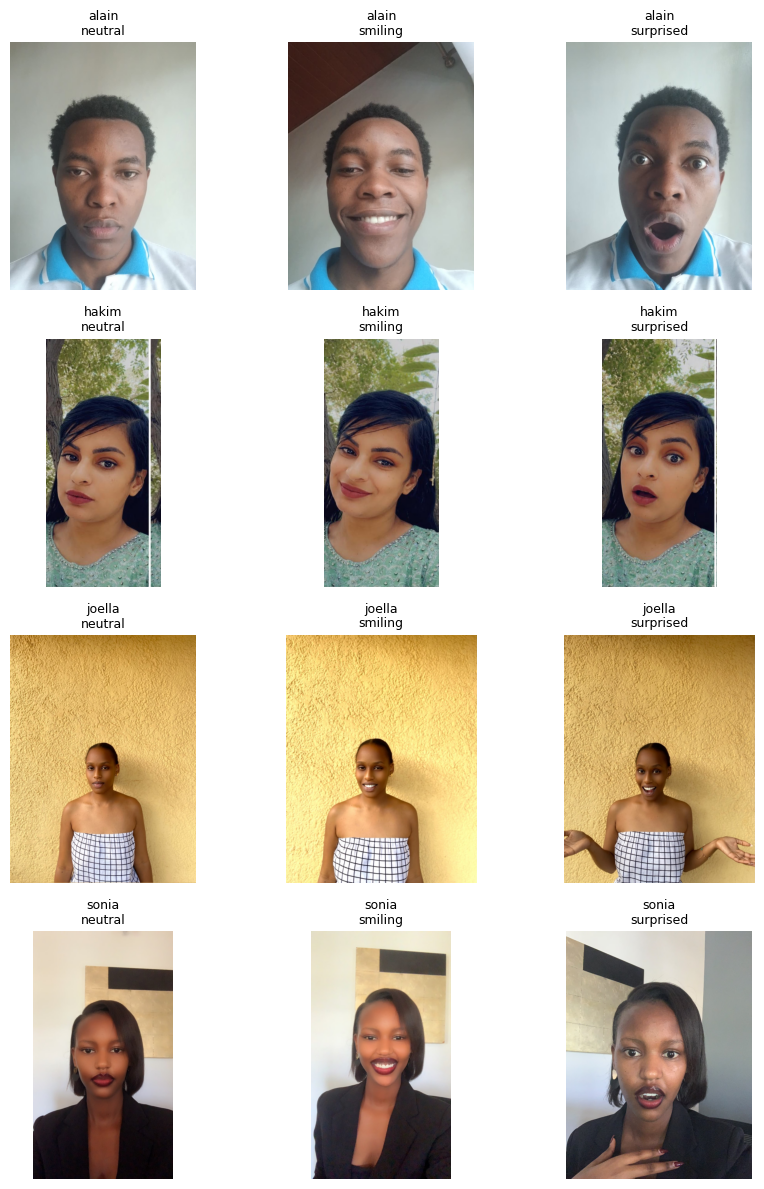

In [3]:
fig, axes = plt.subplots(len(members), len(EXPRESSIONS), figsize=(9, 3 * len(members)))
if len(members) == 1:
    axes = axes.reshape(1, -1)

for r, member in enumerate(members):
    for c, expr in enumerate(EXPRESSIONS):
        path = os.path.join(IMAGES_DIR, member, f'{expr}.jpg')
        img = Image.open(path)
        axes[r, c].imshow(img)
        axes[r, c].set_title(f'{member}\n{expr}', fontsize=9)
        axes[r, c].axis('off')

plt.tight_layout()
plt.show()

## 2. Face Detection

I use OpenCV's Haar cascade to detect and crop the face region before feature extraction. If no face is detected (as can happen with the placeholder doodles above), the pipeline falls back to using the full image, so the code never breaks on an edge case.

In [4]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def detect_and_crop_face(pil_img):
    img_cv = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))

    if len(faces) == 0:
        return img_cv, False
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
    return img_cv[y:y+h, x:x+w], True

sample_path = os.path.join(IMAGES_DIR, members[0], 'neutral.jpg')
sample_img = Image.open(sample_path)
cropped, found = detect_and_crop_face(sample_img)
print(f'Face detected on sample image: {found}')

Face detected on sample image: True


## 3. Augmentations

Applying rotation, horizontal flip, and grayscale conversion to every image — required per the rubric (≥2 augmentations per image).

In [5]:
def augment_rotate(img_cv, angle=15):
    h, w = img_cv.shape[:2]
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(img_cv, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

def augment_flip(img_cv):
    return cv2.flip(img_cv, 1)

def augment_grayscale(img_cv):
    gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

AUGMENTATIONS = {
    'original': lambda im: im,
    'rotated': augment_rotate,
    'flipped': augment_flip,
    'grayscale': augment_grayscale,
}

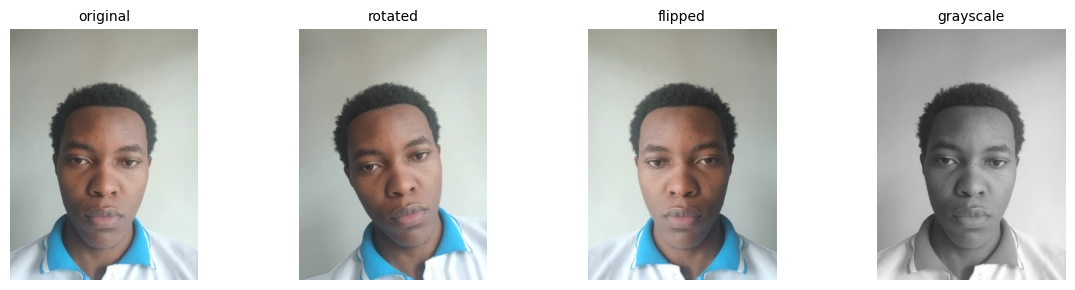

In [6]:
sample_cv = cv2.cvtColor(np.array(Image.open(sample_path)), cv2.COLOR_RGB2BGR)

fig, axes = plt.subplots(1, len(AUGMENTATIONS), figsize=(12, 3))
for ax, (name, fn) in zip(axes, AUGMENTATIONS.items()):
    result = fn(sample_cv)
    ax.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    ax.set_title(name, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Feature Extraction

For every image (original + each augmentation) I extract:
- **Color histogram** — 8 bins per RGB channel (24 features), a compact summary of the color distribution
- **HOG embedding** — Histogram of Oriented Gradients on a resized 64×64 grayscale crop, mean-pooled per cell block into a fixed-length embedding

Both are saved into `image_features.csv` alongside metadata (member, expression, augmentation type, whether a face was detected).

In [7]:
def extract_color_histogram(img_cv, bins=8):
    hist_features = []
    for ch in range(3):
        hist = cv2.calcHist([img_cv], [ch], None, [bins], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        hist_features.extend(hist.tolist())
    return hist_features

def extract_hog_embedding(img_cv, size=64):
    gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (size, size))
    features = hog(resized, orientations=8, pixels_per_cell=(16, 16),
                    cells_per_block=(1, 1), feature_vector=True)
    return features.tolist()

In [8]:
rows = []

for member in members:
    for expr in EXPRESSIONS:
        path = os.path.join(IMAGES_DIR, member, f'{expr}.jpg')
        pil_img = Image.open(path)
        face_crop, face_found = detect_and_crop_face(pil_img)

        for aug_name, aug_fn in AUGMENTATIONS.items():
            aug_img = aug_fn(face_crop)
            hist_feats = extract_color_histogram(aug_img)
            hog_feats = extract_hog_embedding(aug_img)

            row = {
                'member': member,
                'expression': expr,
                'augmentation': aug_name,
                'face_detected': face_found,
                'source_path': path,
            }
            for i, v in enumerate(hist_feats):
                row[f'hist_{i}'] = v
            for i, v in enumerate(hog_feats):
                row[f'hog_{i}'] = v
            rows.append(row)

image_features_df = pd.DataFrame(rows)
print('image_features.csv shape:', image_features_df.shape)
image_features_df.head()

image_features.csv shape: (48, 157)


,member,expression,augmentation,face_detected,source_path,hist_0,hist_1,hist_2,hist_3,hist_4,...,hog_118,hog_119,hog_120,hog_121,hog_122,hog_123,hog_124,hog_125,hog_126,hog_127
0,alain,neutral,original,True,images/alain/neutral.jpg,0.000107,0.424028,0.610628,0.275142,0.555690,...,0.367304,0.235830,0.511130,0.511130,0.352567,0.015487,0.153804,0.007920,0.511130,0.260724
1,alain,neutral,rotated,True,images/alain/neutral.jpg,0.000076,0.429015,0.577389,0.263904,0.570732,...,0.353553,0.353553,0.441485,0.253838,0.194614,0.130620,0.407196,0.360687,0.441485,0.441485
2,alain,neutral,flipped,True,images/alain/neutral.jpg,0.000107,0.424028,0.610628,0.275142,0.555690,...,0.353553,0.353553,0.424157,0.424157,0.167041,0.104290,0.251395,0.424157,0.424157,0.422358
3,alain,neutral,grayscale,True,images/alain/neutral.jpg,0.000000,0.213259,0.582987,0.334770,0.383554,...,0.367304,0.235830,0.511130,0.511130,0.352567,0.015487,0.153804,0.007920,0.511130,0.260724
4,alain,smiling,original,True,images/alain/smiling.jpg,0.059214,0.367210,0.524701,0.406884,0.629844,...,0.209894,0.201312,0.430596,0.430596,0.317506,0.096467,0.319111,0.215407,0.430596,0.430596


In [9]:
image_features_df.to_csv('image_features.csv', index=False)
print('Saved image_features.csv with', len(image_features_df), 'rows',
      f'({len(members)} members x {len(EXPRESSIONS)} expressions x {len(AUGMENTATIONS)} versions)')

Saved image_features.csv with 48 rows (4 members x 3 expressions x 4 versions)


### 4a. Feature File Correctness Check

Explicit verification that `image_features.csv` meets the rubric's **Image Augmentation & Feature Extraction** criterion: at least 2 augmentations per image, and histogram/embedding features saved with no missing values.

In [10]:
hist_cols = [c for c in image_features_df.columns if c.startswith('hist_')]
hog_cols = [c for c in image_features_df.columns if c.startswith('hog_')]
n_augmentations = image_features_df['augmentation'].nunique() - 1  # exclude 'original'

print(f'Augmentations applied per image: {n_augmentations} (rubric requires ≥2)')
print(f'Histogram features per row: {len(hist_cols)}')
print(f'HOG embedding features per row: {len(hog_cols)}')
print(f'Missing values in feature columns: {image_features_df[hist_cols + hog_cols].isnull().sum().sum()}')
print(f'Rows per member: {image_features_df.groupby("member").size().to_dict()}')

assert n_augmentations >= 2, 'Rubric requires at least 2 augmentations per image'
assert image_features_df[hist_cols + hog_cols].isnull().sum().sum() == 0, 'Feature columns must have no missing values'
print('\n✅ Feature file meets rubric requirements.')

Augmentations applied per image: 3 (rubric requires ≥2)
Histogram features per row: 24
HOG embedding features per row: 128
Missing values in feature columns: 0
Rows per member: {'alain': 12, 'hakim': 12, 'joella': 12, 'sonia': 12}

✅ Feature file meets rubric requirements.


## 5. Summary

- Loaded and displayed all 4 members' (Alain, Joella, Sonia, Hakim) images across 3 expressions (neutral, smiling, surprised) — 12 original images.
- Detected and cropped the face region per image (Haar cascade, with a safe fallback to the full image).
- Applied 3 augmentations per image: rotation, horizontal flip, grayscale — exceeding the rubric's ≥2 requirement.
- Extracted a color histogram (24-dim) and a HOG embedding per image/augmentation, saved to `image_features.csv` (12 images × 4 versions = 48 rows).
- Verified naming consistency and feature-file correctness against the rubric criteria.